# Paper Results from Hashed Weights

Regenerates every number and figure in the HTO manuscript that depends on the trained single-stage models, from the six archived checkpoints in `weights/`, **with no training**. Each result is tied to the SHA-256 of the weights that produced it.

| Paper item | Source here | Model(s) |
| --- | --- | --- |
| Table 1 — 5-fold CV column; headline 0.46° / 1.37° / ICC 0.992 | Section A | 5 fold models, each on its own validation fold |
| Fig. 2 — per-fold keypoint MSE, PCK, angle MAE | Section A | 5 fold models |
| Fig. 3 — Bland–Altman (CV) | Section A | 5 fold models |
| Table 1 — Test column | Section B | final global model |
| Fig. 4 — CV circles + test triangles | A + B | fold models + global |
| Fig. 5 — example test radiograph | Section B | global |
| Fig. 1 — training progression | Section D (re-plotted from the saved training log) | global's training run |
| Table 2 — "This work" column | Section C | derived from A + B |

Not covered here: the OAI external validation (`hto_oai_external_validation_multimodel.ipynb`), the ablations and the two-stage experiments (their own notebooks and models).

**How the splits are reproduced.** The 54 radiographs are sorted by path and shuffled with seed 42 exactly as in `hto_correction_angles.ipynb`. The CV folds come from `KFold(n_splits=5, shuffle=True, random_state=42)`; the test split is the last 10% of the shuffled list. Each fold's validation files and the test files are printed and fingerprinted.

**Expected differences from the manuscript**
- *CV column*: should agree within rounding plus about 0.02° of GPU numerical noise. Anything larger means these fold files did not produce the published CV results.
- *Test column*: the manuscript's test figures came from the global model that existed before 22 June; the hashed global model here replaced it, so the test column is expected to change.
- *PCK*: the training notebook reports each fold's "best PCK" as the maximum over all epochs, per threshold. Rescoring a checkpoint gives the PCK **of that checkpoint**, which can be slightly lower. The checkpoint value is the one that belongs to the model you report.
- *GPU*: heatmap peaks are decoded by argmax, so tiny floating-point differences between GPUs occasionally move a landmark by one heatmap pixel (≈0.3° in one hemisphere's angle). The GPU used is recorded.

**Setup.** The container sees `weights/` only if `docker-compose.yml` mounts it: `- ./weights:/tf/weights`. Outputs go to `paper_results/`.

## Imports & Configuration

In [1]:
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")   # required by deterministic cuBLAS; must precede CUDA init
import sys, json, math, random, hashlib, datetime, re
import numpy as np
import pandas as pd
import torch
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold

for _ckd in ("CKD", "/tf/notebooks/CKD", os.path.join(os.getcwd(), "CKD")):
    if os.path.isdir(_ckd):
        sys.path.append(os.path.abspath(_ckd)); break
else:
    sys.path.append(os.path.abspath("CKD"))
from models import (
    Conformer_tiny_patch16_keypoint_half_heatmap,
    Conformer_small_patch16_keypoint_half_heatmap,
    Conformer_small_patch32_keypoint_half_heatmap,
    Conformer_base_patch16_keypoint_half_heatmap,
)
from utils import extract_coordinates

# ---- must match hto_correction_angles.ipynb -------------------------------------------
DATA_DIR       = "/tf/data/hto/xrays"
COCO_JSON_PATH = os.path.join(DATA_DIR, "hto_annotations.json")
if not os.path.exists(COCO_JSON_PATH):
    COCO_JSON_PATH = "hto_annotations.json"
SEED           = 42
TARGET_SIZE    = 768
HEATMAP_SCALE  = 0.5
SIGMA          = 6.0
SPLIT_RATIOS   = (0.8, 0.1, 0.1)
N_FOLDS        = 5
BATCH_SIZE     = 4
MODEL_VARIANT  = "small_p16"
CLINICAL_TOLERANCE_DEG = 1.63
PCK_THRESHOLDS = [0.005, 0.01, 0.02, 0.05]

# ---- weights under test (SHA-256 recorded 2026-09-19) -------------------------------------
WEIGHTS_DIR_CANDIDATES = ["/tf/weights", os.path.join("..", "weights"), "weights"]
MODELS = {   # label -> (file, expected sha256)
    "fold1":  ("best_model_fold1.pt",  "d8fc080614798a363ad9c36fbf6dd9783e9b445073fe77e9e3fc58f9644eda32"),
    "fold2":  ("best_model_fold2.pt",  "07104cca50b27ae512f15728b8634c5edebec5bd07cd8a9d70d33f0addf28446"),
    "fold3":  ("best_model_fold3.pt",  "6779803fd8085cd725e842dbd3d37d5092e818ce4510effd2297d505e3dc4f71"),
    "fold4":  ("best_model_fold4.pt",  "a0ab4ebce5f321df63ff6628c0eb950e3c49672f9e3af177e6e70272bc72e657"),
    "fold5":  ("best_model_fold5.pt",  "083e0649067b29f79a9b060de19e3456d6b07e89ee41bdbe07ca5258463d8663"),
    "global": ("best_model_global.pt", "20cb99afb0f7455d3c2a71494b586930439b761bbb23482d1d05a977955186d0"),
}

# ---- published values (manuscript v2), for comparison ------------------------------------
PAPER = {
    "cv":   dict(mean=0.46, median=0.41, std=0.31, max=1.37, rmse=0.55, icc=0.992, pearson=0.993,
                 within_tol_pct=100.0, ba_bias=-0.06, ba_loa_low=-1.14, ba_loa_high=1.02),
    "test": dict(mean=0.48, median=0.45, std=0.35, max=1.06, rmse=0.59, icc=0.987, pearson=0.987,
                 within_tol_pct=100.0),
    "keypoints": dict(mse_mean=4.76, mse_sd=0.76, pck_0005=96.5, pck_0005_sd=1.1, pck_001=99.8,
                      pck_001_sd=0.3, pck_002=100.0, pck_005=100.0, fold_mae_min=0.33, fold_mae_max=0.55),
    "fig5_errors": (0.15, 0.72),
}

FIG5_FILE         = "32_0.png"                   # the manuscript's Fig. 5 example (per-limb errors 0.15° / 0.72° with the old model)
TRAINING_NOTEBOOK = "hto_correction_angles.ipynb"   # holds the saved 2000-epoch log of the global model's training run
OUT_DIR           = "paper_results"

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GPU_NAME = torch.cuda.get_device_name(0) if device.type == "cuda" else None
os.makedirs(OUT_DIR, exist_ok=True)

WEIGHTS_DIR = next((d for d in WEIGHTS_DIR_CANDIDATES if os.path.isdir(d)), None)
assert WEIGHTS_DIR is not None, ("weights/ not found. Add '- ./weights:/tf/weights' under volumes: "
                                 "in docker-compose.yml and restart the container.")
print(f"torch {torch.__version__} | device {device}" + (f" | {GPU_NAME}" if GPU_NAME else ""))
print(f"weights: {os.path.abspath(WEIGHTS_DIR)} | outputs: {os.path.abspath(OUT_DIR)}")

torch 2.5.1+cu121 | device cuda | NVIDIA GeForce RTX 4070 Laptop GPU
weights: /tf/weights | outputs: /tf/notebooks/paper_results


/usr/local/lib/python3.11/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/tf/notebooks/CKD/vision_transformer.py:370: UserWarning: Overwriting vit_small_patch16_224 in registry with vision_transformer.vit_small_patch16_224. This is because the name being registe

## Weight Manifest

In [2]:
def sha256_file(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

_rows = []
for label, (fname, expected) in MODELS.items():
    p = os.path.join(WEIGHTS_DIR, fname); st = os.stat(p); digest = sha256_file(p)
    _rows.append(dict(model=label, file=fname, bytes=st.st_size,
                      modified=datetime.datetime.fromtimestamp(st.st_mtime).isoformat(timespec="seconds"),
                      sha256=digest, matches_expected=(digest == expected)))
MANIFEST = pd.DataFrame(_rows)
SHA = dict(zip(MANIFEST["model"], MANIFEST["sha256"]))
with pd.option_context("display.max_colwidth", 80, "display.width", 200):
    print(MANIFEST[["model", "file", "modified", "sha256", "matches_expected"]].to_string(index=False))
MANIFEST.to_csv(os.path.join(OUT_DIR, "weights_manifest.csv"), index=False)
print("\n" + ("All six files match the recorded SHA-256." if MANIFEST["matches_expected"].all() else
              "WARNING: hash mismatch — " + ", ".join(MANIFEST.loc[~MANIFEST.matches_expected, "file"])
              + ". Results will not correspond to the recorded models."))

 model                 file            modified                                                           sha256  matches_expected
 fold1  best_model_fold1.pt 2026-06-21T00:07:28 d8fc080614798a363ad9c36fbf6dd9783e9b445073fe77e9e3fc58f9644eda32              True
 fold2  best_model_fold2.pt 2026-06-21T06:07:41 07104cca50b27ae512f15728b8634c5edebec5bd07cd8a9d70d33f0addf28446              True
 fold3  best_model_fold3.pt 2026-06-21T11:47:19 6779803fd8085cd725e842dbd3d37d5092e818ce4510effd2297d505e3dc4f71              True
 fold4  best_model_fold4.pt 2026-06-21T18:23:09 a0ab4ebce5f321df63ff6628c0eb950e3c49672f9e3af177e6e70272bc72e657              True
 fold5  best_model_fold5.pt 2026-06-22T01:35:05 083e0649067b29f79a9b060de19e3456d6b07e89ee41bdbe07ca5258463d8663              True
global best_model_global.pt 2026-06-22T10:24:47 20cb99afb0f7455d3c2a71494b586930439b761bbb23482d1d05a977955186d0              True

All six files match the recorded SHA-256.


## Preprocessing & Dataset
Verbatim from `hto_correction_angles.ipynb` (augmentation omitted — it applies only to the train split).

In [3]:
def preprocess_global_image(img, target_size=512):
    """Letterbox-resize *img* to a square canvas of *target_size* pixels."""
    orig_w, orig_h = img.size
    scale   = min(target_size / orig_w, target_size / orig_h)
    new_w   = int(orig_w * scale)
    new_h   = int(orig_h * scale)
    resized = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    pad_left = (target_size - new_w) // 2
    pad_top  = (target_size - new_h) // 2
    final_img = Image.new("RGB", (target_size, target_size), (0, 0, 0))
    final_img.paste(resized, (pad_left, pad_top))
    return final_img, scale, (pad_left, pad_top)


def _rep_x(ann):
    """Representative x-coordinate for hemisphere assignment (mean of visible keypoint x)."""
    kps = ann.get("keypoints", [])
    xs  = [kps[i] for i in range(0, len(kps), 3) if kps[i] > 0]
    if xs:
        return sum(xs) / len(xs)
    bbox = ann.get("bbox", [0, 0, 0, 0])
    return bbox[0] + bbox[2] / 2


class GlobalRadiographKeypointDataset(Dataset):
    """COCO-style dataset for global 12-keypoint detection (verbatim from the training notebook)."""

    def __init__(self, coco_json_path, split="train", split_ratios=(0.8, 0.1, 0.1),
                 target_size=512, heatmap_scale=0.25, sigma=2.0, seed=42, indices=None):
        super().__init__()
        self.target_size   = target_size
        self.heatmap_scale = heatmap_scale
        self.sigma         = sigma
        self.num_keypoints = 12
        self.split         = split

        with open(coco_json_path, "r") as f:
            coco_data = json.load(f)
        images_info = {img["id"]: img for img in coco_data.get("images", [])}
        anns_by_img = {}
        for ann in coco_data.get("annotations", []):
            anns_by_img.setdefault(ann.get("image_id"), []).append(ann)

        valid_samples = []
        for img_id, anns in anns_by_img.items():
            if img_id not in images_info:
                continue
            img_info = images_info[img_id]
            img_w    = img_info.get("width", 2860)
            by_cat = {}
            for ann in anns:
                by_cat.setdefault(ann.get("category_id"), []).append(ann)

            kps_flat = [-1.0, -1.0, 0] * 12
            has_kp   = False
            for cat_id, cat_anns in by_cat.items():
                sorted_anns = sorted(cat_anns, key=_rep_x)
                if len(sorted_anns) == 2:
                    assignments = [(sorted_anns[0], 0), (sorted_anns[1], 6)]
                elif len(sorted_anns) == 1:
                    x    = _rep_x(sorted_anns[0])
                    base = 0 if x < img_w / 2.0 else 6
                    assignments = [(sorted_anns[0], base)]
                else:
                    assignments = [(sorted_anns[0], 0), (sorted_anns[-1], 6)]

                for ann, base in assignments:
                    kps = ann.get("keypoints", [])
                    if cat_id == 1 and len(kps) >= 3:
                        kps_flat[base * 3:(base + 1) * 3] = [kps[0], kps[1], 2 if kps[0] > 0 else 0]
                        if kps[0] > 0:
                            has_kp = True
                    elif cat_id == 2 and len(kps) >= 9:
                        for k in range(3):
                            s = base + 1 + k
                            kps_flat[s * 3:(s + 1) * 3] = [kps[k * 3], kps[k * 3 + 1], kps[k * 3 + 2]]
                            if kps[k * 3 + 2] > 0:
                                has_kp = True
                    elif cat_id == 3 and len(kps) >= 6:
                        for k in range(2):
                            s = base + 4 + k
                            kps_flat[s * 3:(s + 1) * 3] = [kps[k * 3], kps[k * 3 + 1], kps[k * 3 + 2]]
                            if kps[k * 3 + 2] > 0:
                                has_kp = True

            if has_kp:
                filename = img_info.get("file_name")
                img_dir  = os.path.dirname(coco_json_path) or "."
                if not os.path.exists(os.path.join(img_dir, filename)):
                    alt = os.path.join("/tf/data/hto/xrays", os.path.basename(filename))
                    if os.path.exists(alt):
                        img_dir = "/tf/data/hto/xrays"
                valid_samples.append({
                    "img_path":  os.path.join(img_dir, filename),
                    "orig_size": (img_w, img_info.get("height", 8000)),
                    "keypoints": kps_flat,
                })

        # deterministic shuffle, then split
        valid_samples.sort(key=lambda x: x["img_path"])
        random.seed(seed)
        random.shuffle(valid_samples)
        if indices is not None:
            self.samples = [valid_samples[i] for i in indices]
        else:
            n         = len(valid_samples)
            train_end = int(n * split_ratios[0])
            val_end   = train_end + int(n * split_ratios[1])
            self.samples = {"train": valid_samples[:train_end],
                            "val":   valid_samples[train_end:val_end],
                            "test":  valid_samples[val_end:]}.get(split, valid_samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        try:
            img = Image.open(sample["img_path"]).convert("RGB")
        except Exception:
            img = Image.new("RGB", sample["orig_size"], color=(128, 128, 128))
        processed_img, scale, padding = preprocess_global_image(img, self.target_size)

        final_kps, kp_visibility = [], []
        for i in range(self.num_keypoints):
            kp_x = sample["keypoints"][i * 3]; kp_y = sample["keypoints"][i * 3 + 1]; kp_v = sample["keypoints"][i * 3 + 2]
            if kp_v > 0 and kp_x >= 0 and kp_y >= 0:
                final_kps.append([kp_x * scale + padding[0], kp_y * scale + padding[1]]); kp_visibility.append(1.0)
            else:
                final_kps.append([-1.0, -1.0]); kp_visibility.append(0.0)

        img_tensor = torch.from_numpy(np.array(processed_img)).permute(2, 0, 1).float() / 255.0
        img_tensor = (img_tensor - torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)) \
                     / torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        return {"image": img_tensor,
                "keypoint": torch.tensor(final_kps, dtype=torch.float32),
                "visibility": torch.tensor(kp_visibility, dtype=torch.float32),
                "img_path": sample["img_path"],
                "orig_size": torch.tensor(sample["orig_size"])}

## Geometry, Keypoint Metrics & Agreement Statistics
Verbatim from `hto_correction_angles.ipynb`.

In [4]:
def map_global_to_orig(kp_final, orig_size, target_size=512):
    """Invert the letterbox transform back to original image coordinates."""
    orig_w, orig_h = orig_size
    scale    = min(target_size / orig_w, target_size / orig_h)
    pad_left = (target_size - int(orig_w * scale)) // 2
    pad_top  = (target_size - int(orig_h * scale)) // 2
    return np.array([(kp_final[0] - pad_left) / scale, (kp_final[1] - pad_top) / scale])


def calculate_intersection(p1, p2, target_y):
    """X-coordinate where line (p1 -> p2) crosses y = *target_y*."""
    if p2[0] == p1[0]: return p1[0]
    m = (p2[1] - p1[1]) / (p2[0] - p1[0])
    if m == 0:
        return p1[0] if abs(target_y - p1[1]) < 1e-9 else float("nan")
    return (target_y - p1[1]) / m + p1[0]


def evaluate_side_geometry(points):
    """Miniaci correction angle for one hemisphere -> (alpha, fujisawa, ankle_c, target_at_ankle)."""
    ankle_c  = (points["ankle_inner"] + points["ankle_outer"]) / 2.0
    fujisawa = points["knee_inner"] + 0.625 * (points["knee_outer"] - points["knee_inner"])
    tx              = calculate_intersection(points["femur_head"], fujisawa, ankle_c[1])
    target_at_ankle = np.array([tx, ankle_c[1]])
    v_orig   = ankle_c         - points["ost_point"]
    v_target = target_at_ankle - points["ost_point"]
    raw      = abs(math.atan2(v_orig[1], v_orig[0]) - math.atan2(v_target[1], v_target[0]))
    alpha    = min(raw, 2 * math.pi - raw) * 180.0 / math.pi
    return alpha, fujisawa, ankle_c, target_at_ankle


_SIDE_KEYS = ["femur_head", "knee_inner", "ost_point", "knee_outer", "ankle_inner", "ankle_outer"]


def icc21_manual(ratings):
    ratings = np.asarray(ratings, dtype=float); n, k = ratings.shape; grand = ratings.mean()
    row_means = ratings.mean(axis=1, keepdims=True); col_means = ratings.mean(axis=0, keepdims=True)
    ss_total = ((ratings - grand) ** 2).sum()
    ss_row = k * ((row_means - grand) ** 2).sum(); ss_col = n * ((col_means - grand) ** 2).sum()
    ss_err = ss_total - ss_row - ss_col
    ms_row = ss_row / (n - 1); ms_col = ss_col / (k - 1); ms_err = ss_err / ((n - 1) * (k - 1))
    return float((ms_row - ms_err) / (ms_row + (k - 1) * ms_err + (k / n) * (ms_col - ms_err)))


def compute_icc(gt, pred):
    gt = np.asarray(gt, dtype=float); pred = np.asarray(pred, dtype=float); n = len(gt)
    try:
        import pingouin as pg
        long = pd.DataFrame({"target": list(range(n)) * 2,
                             "rater": ["mean_observer"] * n + ["auto"] * n,
                             "angle": np.concatenate([gt, pred])})
        res = pg.intraclass_corr(data=long, targets="target", raters="rater", ratings="angle")
        row = res.loc[res["Type"].isin(["ICC2", "ICC(A,1)"])].iloc[0]
        ci = row["CI95%" if "CI95%" in res.columns else "CI95"]
        return float(row["ICC"]), float(ci[0]), float(ci[1]), "pingouin ICC(2,1)"
    except ImportError:
        return (icc21_manual(np.column_stack([gt, pred])), np.nan, np.nan,
                "manual ICC(2,1) -- pip install pingouin for the 95% CI")


def angle_agreement_report(gt, pred, tolerance=CLINICAL_TOLERANCE_DEG, label=""):
    gt = np.asarray(gt, dtype=float); pred = np.asarray(pred, dtype=float)
    diff = pred - gt; abs_err = np.abs(diff)
    icc, lo, hi, method = compute_icc(gt, pred)
    bias = diff.mean(); sd_diff = diff.std(ddof=1)
    loa_low, loa_high = bias - 1.96 * sd_diff, bias + 1.96 * sd_diff
    pearson = np.corrcoef(gt, pred)[0, 1] if len(gt) > 1 else float("nan")
    within = 100.0 * np.mean(abs_err <= tolerance); rmse = float(np.sqrt(np.mean(diff ** 2)))
    ci_str = "" if np.isnan(lo) else f" ({lo:.3f}-{hi:.3f} 95% CI)"
    print("=" * 64); print(f"  {label}   (n = {len(gt)} limb hemispheres)"); print("=" * 64)
    print("Absolute correction-angle error (degrees)")
    print(f"  mean    : {abs_err.mean():.4f}");  print(f"  median  : {np.median(abs_err):.4f}")
    print(f"  std     : {abs_err.std(ddof=1):.4f}"); print(f"  min     : {abs_err.min():.4f}")
    print(f"  max     : {abs_err.max():.4f}");   print(f"  RMSE    : {rmse:.4f}")
    print(f"  within +/-{tolerance:.2f} deg : {within:.1f}%")
    print("\nAgreement"); print(f"  ICC(2,1) : {icc:.3f}{ci_str}   [{method}]"); print(f"  Pearson r: {pearson:.4f}")
    print("\nBland-Altman (predicted - GT)")
    print(f"  bias (mean diff)       : {bias:+.4f}")
    print(f"  95% limits of agreement: [{loa_low:+.4f}, {loa_high:+.4f}]")
    print("=" * 64 + "\n")
    return {"label": label, "n": int(len(gt)), "mean": float(abs_err.mean()), "median": float(np.median(abs_err)),
            "std": float(abs_err.std(ddof=1)), "min": float(abs_err.min()), "max": float(abs_err.max()),
            "rmse": rmse, "within_tol_pct": float(within), "icc": float(icc), "icc_lo": float(lo),
            "icc_hi": float(hi), "ba_bias": float(bias), "ba_loa_low": float(loa_low),
            "ba_loa_high": float(loa_high), "pearson": float(pearson)}


def calculate_mse(preds, gts):
    """Mean Squared Error (px²) over all valid keypoints (768-px canvas)."""
    valid_mask = gts[..., 0] >= 0
    if not torch.any(valid_mask): return 0.0
    return torch.mean(torch.sum((preds - gts) ** 2, dim=-1)[valid_mask]).item()


def calculate_pck(preds, gts, threshold=0.05, normalize_by=512):
    """Percentage of Correct Keypoints at *threshold* × *normalize_by* px."""
    valid_mask = gts[..., 0] >= 0
    if not torch.any(valid_mask): return 0.0
    correct = torch.norm(preds - gts, dim=-1) < (threshold * normalize_by)
    return torch.mean(correct[valid_mask].float()).item()

## Model Loading & Scoring

In [5]:
_model_map = {
    "tiny":      Conformer_tiny_patch16_keypoint_half_heatmap,
    "small_p16": Conformer_small_patch16_keypoint_half_heatmap,
    "small_p32": Conformer_small_patch32_keypoint_half_heatmap,
    "base":      Conformer_base_patch16_keypoint_half_heatmap,
}

def load_model(label):
    m = _model_map[MODEL_VARIANT](num_keypoints=12).to(device)
    m.load_state_dict(torch.load(os.path.join(WEIGHTS_DIR, MODELS[label][0]), weights_only=True, map_location=device))
    return m.eval()


def score(model, dataset, label):
    """Run *model* over *dataset*. Returns (per-hemisphere angle table, keypoint metrics, per-image coords)."""
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    rows, preds, gts, per_image = [], [], [], {}
    with torch.no_grad():
        for batch in loader:
            coords = extract_coordinates(torch.sigmoid(model(batch["image"].to(device))).cpu(),
                                         scale_factor=1.0 / HEATMAP_SCALE)
            preds.append(coords); gts.append(batch["keypoint"])
            cn, gn, osz = coords.numpy(), batch["keypoint"].numpy(), batch["orig_size"].numpy()
            for b in range(len(cn)):
                fname = os.path.basename(batch["img_path"][b])
                per_image[fname] = dict(pred=cn[b], gt=gn[b], orig_size=osz[b], img_path=batch["img_path"][b])
                for base, side in [(0, "left"), (6, "right")]:
                    pts_gt, pts_pred = {}, {}
                    for k_off, name in enumerate(_SIDE_KEYS):
                        slot = base + k_off
                        if gn[b][slot][0] >= 0:
                            pts_gt[name]   = map_global_to_orig(gn[b][slot], osz[b], TARGET_SIZE)
                            pts_pred[name] = map_global_to_orig(cn[b][slot], osz[b], TARGET_SIZE)
                    if all(k in pts_gt for k in _SIDE_KEYS) and all(k in pts_pred for k in _SIDE_KEYS):
                        g, *_ = evaluate_side_geometry(pts_gt)
                        p, *_ = evaluate_side_geometry(pts_pred)
                        rows.append(dict(model=label, sha256=SHA[label], file=fname, image_hemisphere=side,
                                         gt_angle=float(g), pred_angle=float(p), error=float(p - g),
                                         abs_error=float(abs(p - g))))
    P, G = torch.cat(preds), torch.cat(gts)
    kp = dict(mse=calculate_mse(P, G),
              **{f"pck@{t}": 100 * calculate_pck(P, G, threshold=t, normalize_by=TARGET_SIZE) for t in PCK_THRESHOLDS})
    return pd.DataFrame(rows), kp, per_image


def fingerprint(files):
    return hashlib.sha256("\n".join(sorted(files)).encode()).hexdigest()

assert os.path.exists(COCO_JSON_PATH), f"annotation file not found: {COCO_JSON_PATH}"
_kw = dict(target_size=TARGET_SIZE, heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED)
full_ds = GlobalRadiographKeypointDataset(COCO_JSON_PATH, split="all", **_kw)
print(f"radiographs: {len(full_ds)}")

radiographs: 54


## A. Five-Fold Cross-Validation (fold models)

Each `best_model_fold<k>.pt` is scored on its own validation fold, rebuilt with the same `KFold` call as the training notebook. Pooled over folds, this is the manuscript's CV column (n ≈ 107 hemispheres).

In [6]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
cv_parts, fold_rows, FOLD_FILES = [], [], {}
for k, (train_idx, val_idx) in enumerate(kf.split(np.arange(len(full_ds))), start=1):
    label = f"fold{k}"
    val_ds = GlobalRadiographKeypointDataset(COCO_JSON_PATH, split="val", indices=val_idx, **_kw)
    FOLD_FILES[label] = [os.path.basename(s["img_path"]) for s in val_ds.samples]
    model = load_model(label)
    H, kp, _ = score(model, val_ds, label)
    del model
    if device.type == "cuda": torch.cuda.empty_cache()
    H.insert(0, "fold", k); cv_parts.append(H)
    a = H["abs_error"].values
    fold_rows.append(dict(fold=k, model=label, sha256=SHA[label], val_images=len(val_ds), hemispheres=len(H),
                          val_files_sha256=fingerprint(FOLD_FILES[label]), kp_mse=kp["mse"],
                          **{f"pck_{t}": kp[f"pck@{t}"] for t in PCK_THRESHOLDS},
                          angle_mae=a.mean(), angle_std=a.std(), angle_max=a.max()))   # population SD, as in evaluate_fold_angles
    print(f"{label}: {len(val_ds)} images, {len(H)} hemispheres | MSE {kp['mse']:.2f} px² | "
          f"PCK@0.005 {kp['pck@0.005']:.1f}% | angle MAE {a.mean():.3f}° max {a.max():.3f}°")

CV = pd.concat(cv_parts, ignore_index=True)
FOLDS = pd.DataFrame(fold_rows)
CV.to_csv(os.path.join(OUT_DIR, "cv_hemispheres.csv"), index=False)
FOLDS.to_csv(os.path.join(OUT_DIR, "cv_folds.csv"), index=False)

print()
cv_stats = angle_agreement_report(CV["gt_angle"].values, CV["pred_angle"].values,
                                  label="5-fold CV (pooled across folds, hashed fold models)")
KP = dict(mse_mean=FOLDS.kp_mse.mean(), mse_sd=FOLDS.kp_mse.std(ddof=0),
          **{f"pck_{t}": FOLDS[f"pck_{t}"].mean() for t in PCK_THRESHOLDS},
          **{f"pck_{t}_sd": FOLDS[f"pck_{t}"].std(ddof=0) for t in PCK_THRESHOLDS},
          fold_mae_min=FOLDS.angle_mae.min(), fold_mae_max=FOLDS.angle_mae.max())
print(f"Keypoint MSE: {KP['mse_mean']:.2f} ± {KP['mse_sd']:.2f} px²   (paper 4.76 ± 0.76)")
for t, ref in [(0.005, "96.5 ± 1.1"), (0.01, "99.8 ± 0.3"), (0.02, "100"), (0.05, "100")]:
    print(f"PCK@{t:<5}: {KP[f'pck_{t}']:.1f} ± {KP[f'pck_{t}_sd']:.1f}%   (paper {ref}; paper = max over epochs)")
print(f"Per-fold angle MAE: {KP['fold_mae_min']:.2f}–{KP['fold_mae_max']:.2f}°   (paper 0.33–0.55°)")

fold1: 11 images, 22 hemispheres | MSE 6.24 px² | PCK@0.005 95.5% | angle MAE 0.527° max 1.372°
fold2: 11 images, 21 hemispheres | MSE 4.33 px² | PCK@0.005 94.7% | angle MAE 0.468° max 1.350°
fold3: 11 images, 22 hemispheres | MSE 4.57 px² | PCK@0.005 93.9% | angle MAE 0.455° max 0.903°
fold4: 11 images, 22 hemispheres | MSE 4.00 px² | PCK@0.005 97.7% | angle MAE 0.472° max 1.027°
fold5: 10 images, 20 hemispheres | MSE 4.70 px² | PCK@0.005 95.8% | angle MAE 0.344° max 0.825°

  5-fold CV (pooled across folds, hashed fold models)   (n = 107 limb hemispheres)
Absolute correction-angle error (degrees)
  mean    : 0.4550
  median  : 0.4066
  std     : 0.3126
  min     : 0.0178
  max     : 1.3722
  RMSE    : 0.5512
  within +/-1.63 deg : 100.0%

Agreement
  ICC(2,1) : 0.992 (0.990-0.990 95% CI)   [pingouin ICC(2,1)]
  Pearson r: 0.9929

Bland-Altman (predicted - GT)
  bias (mean diff)       : -0.0666
  95% limits of agreement: [-1.1441, +1.0109]

Keypoint MSE: 4.77 ± 0.77 px²   (paper 4.76 

## B. Held-out Test Split (final global model)

In [7]:
test_ds = GlobalRadiographKeypointDataset(COCO_JSON_PATH, split="test", split_ratios=SPLIT_RATIOS, **_kw)
TEST_FILES = [os.path.basename(s["img_path"]) for s in test_ds.samples]
print(f"test split: {len(test_ds)} radiographs | fingerprint {fingerprint(TEST_FILES)[:16]}… | {TEST_FILES}")

model_global = load_model("global")
TEST, test_kp, TEST_IMAGES = score(model_global, test_ds, "global")
TEST.to_csv(os.path.join(OUT_DIR, "test_hemispheres.csv"), index=False)
print()
test_stats = angle_agreement_report(TEST["gt_angle"].values, TEST["pred_angle"].values,
                                    label=f"Held-out test split — global ({SHA['global'][:12]}…)")

test split: 6 radiographs | fingerprint 8722c0823d711dd5… | ['30_0.png', '32_0.png', '69_0.png', '13_0.png', '20_0.png', '59_0.png']

  Held-out test split — global (20cb99afb0f7…)   (n = 12 limb hemispheres)
Absolute correction-angle error (degrees)
  mean    : 0.4124
  median  : 0.3156
  std     : 0.3532
  min     : 0.0246
  max     : 1.3416
  RMSE    : 0.5333
  within +/-1.63 deg : 100.0%

Agreement
  ICC(2,1) : 0.989 (0.960-1.000 95% CI)   [pingouin ICC(2,1)]
  Pearson r: 0.9887

Bland-Altman (predicted - GT)
  bias (mean diff)       : -0.0474
  95% limits of agreement: [-1.1349, +1.0401]



## C. Table 1 and Table 2 — regenerated vs published

Δ = regenerated − published. For the CV column the verdict tests whether these fold files produced the published numbers (tolerance: rounding + GPU noise). For the test column a difference is expected, because the published test figures came from the replaced pre-22-June model.

In [8]:
TOL = dict(mean=0.03, median=0.03, std=0.03, max=0.03, rmse=0.03, icc=0.003, pearson=0.003,
           within_tol_pct=0.0, ba_bias=0.03, ba_loa_low=0.05, ba_loa_high=0.05)
ROWS = [("Mean absolute error (°)", "mean", 2), ("Median absolute error (°)", "median", 2),
        ("SD of absolute error (°)", "std", 2), ("Maximum absolute error (°)", "max", 2),
        ("RMSE (°)", "rmse", 2), ("ICC(2,1)", "icc", 3), ("Pearson r", "pearson", 3),
        ("Within ±1.63° (%)", "within_tol_pct", 0), ("Bland–Altman bias (°)", "ba_bias", 2),
        ("95% LoA low (°)", "ba_loa_low", 2), ("95% LoA high (°)", "ba_loa_high", 2)]

tab, cv_ok = [], True
for name, key, d in ROWS:
    new_cv, new_te = cv_stats[key], test_stats[key]
    p_cv, p_te = PAPER["cv"].get(key), PAPER["test"].get(key)
    ok = None if p_cv is None else abs(round(new_cv, d) - p_cv) <= TOL[key] + 10 ** -d / 2
    cv_ok = cv_ok and (ok is not False)
    tab.append(dict(metric=name, cv_published=p_cv, cv_regenerated=round(new_cv, d),
                    cv_delta=None if p_cv is None else round(new_cv - p_cv, d + 1),
                    cv_within_noise=ok, test_published=p_te, test_regenerated=round(new_te, d),
                    test_delta=None if p_te is None else round(new_te - p_te, d + 1)))
T1 = pd.DataFrame(tab)
T1.loc[len(T1)] = dict(metric="ICC 95% CI", cv_published="(0.99-0.99)",
                       cv_regenerated=f"({cv_stats['icc_lo']:.2f}-{cv_stats['icc_hi']:.2f})",
                       test_published="(0.96-1.00)",
                       test_regenerated=f"({test_stats['icc_lo']:.2f}-{test_stats['icc_hi']:.2f})")
with pd.option_context("display.width", 200):
    print(T1.to_string(index=False))
T1.to_csv(os.path.join(OUT_DIR, "table1_regenerated_vs_published.csv"), index=False)

print("\nCV column: " + ("CONSISTENT — these fold files reproduce the published CV results within rounding + GPU noise."
                        if cv_ok else
                        "DIFFERS beyond noise — these fold files did not produce the published CV results; see Δ."))
print("Test column: differences are expected (published figures came from the pre-22-June global model).")

print("\nTable 1 for the manuscript (regenerated):")
print(f"{'Metric':<28}{'5-fold CV':>12}{'Test':>12}")
print(f"{'':<28}{'(n = ' + str(cv_stats['n']) + ')':>12}{'(n = ' + str(test_stats['n']) + ')':>12}")
for name, key, d in ROWS[:8]:
    f = (lambda v: f"{v:.0f}%") if key == "within_tol_pct" else (lambda v, d=d: f"{v:.{d}f}")
    print(f"{name:<28}{f(cv_stats[key]):>12}{f(test_stats[key]):>12}")
print(f"{'  95% CI':<28}{T1.iloc[-1]['cv_regenerated']:>12}{T1.iloc[-1]['test_regenerated']:>12}")

print("\nTable 2, 'This work' column (regenerated):")
print(f"  Mean abs error      {cv_stats['mean']:.2f} (CV) / {test_stats['mean']:.2f} (test)")
print(f"  Median abs error    {cv_stats['median']:.2f} (CV)")
print(f"  Max abs error       {cv_stats['max']:.2f} (CV) / {test_stats['max']:.2f} (test)")
print(f"  ICC                 {cv_stats['icc']:.3f} ({cv_stats['icc_lo']:.2f}-{cv_stats['icc_hi']:.2f})")
print(f"  Bland-Altman bias   {cv_stats['ba_bias']:+.2f}")
print(f"  Cases outside ±1.63° {int((CV['abs_error'] > CLINICAL_TOLERANCE_DEG).sum())}")

                    metric cv_published cv_regenerated  cv_delta cv_within_noise test_published test_regenerated  test_delta
   Mean absolute error (°)         0.46           0.45   -0.0050            True           0.48             0.41     -0.0680
 Median absolute error (°)         0.41           0.41   -0.0030            True           0.45             0.32     -0.1340
  SD of absolute error (°)         0.31           0.31    0.0030            True           0.35             0.35      0.0030
Maximum absolute error (°)         1.37           1.37    0.0020            True           1.06             1.34      0.2820
                  RMSE (°)         0.55           0.55    0.0010            True           0.59             0.53     -0.0570
                  ICC(2,1)        0.992          0.992    0.0003            True          0.987            0.989      0.0024
                 Pearson r        0.993          0.993   -0.0001            True          0.987            0.989      0.0017


## Fig. 2 — Five-fold cross-validation summary

Rescored checkpoints. PCK here is the checkpoint's own PCK (the published figure used the per-threshold maximum over epochs).

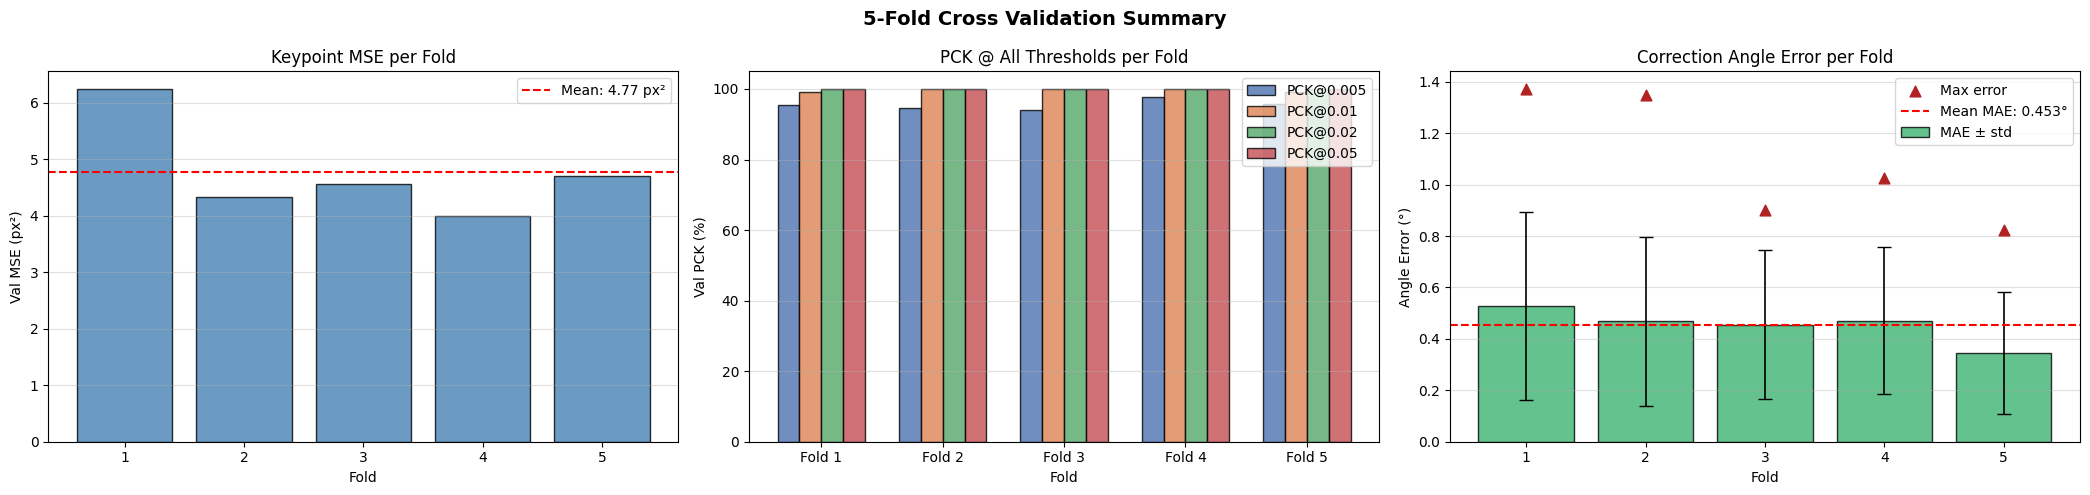

 fold  val_images  hemispheres  kp_mse  pck_0.005  pck_0.01  angle_mae  angle_std  angle_max
    1          11           22   6.240     95.455    99.242      0.527      0.366      1.372
    2          11           21   4.331     94.656   100.000      0.468      0.328      1.350
    3          11           22   4.567     93.939   100.000      0.455      0.289      0.903
    4          11           22   3.998     97.727   100.000      0.472      0.287      1.027
    5          10           20   4.699     95.833    99.167      0.344      0.238      0.825


In [9]:
folds = FOLDS["fold"].tolist()
fig, axes = plt.subplots(1, 3, figsize=(21, 5))
axes[0].bar(folds, FOLDS.kp_mse, color="steelblue", edgecolor="black", alpha=0.8)
axes[0].axhline(FOLDS.kp_mse.mean(), color="red", ls="--", label=f"Mean: {FOLDS.kp_mse.mean():.2f} px²")
axes[0].set_title("Keypoint MSE per Fold"); axes[0].set_xlabel("Fold"); axes[0].set_ylabel("Val MSE (px²)")
axes[0].set_xticks(folds); axes[0].legend(); axes[0].grid(True, axis="y", alpha=0.4)

x = np.arange(len(folds)); w = 0.18
for i, (t, c) in enumerate(zip(PCK_THRESHOLDS, ["#4C72B0", "#DD8452", "#55A868", "#C44E52"])):
    axes[1].bar(x + i * w, FOLDS[f"pck_{t}"], width=w, label=f"PCK@{t}", color=c, edgecolor="black", alpha=0.8)
axes[1].set_title("PCK @ All Thresholds per Fold"); axes[1].set_xlabel("Fold"); axes[1].set_ylabel("Val PCK (%)")
axes[1].set_xticks(x + w * 1.5); axes[1].set_xticklabels([f"Fold {f}" for f in folds])
axes[1].legend(); axes[1].grid(True, axis="y", alpha=0.4)

axes[2].bar(folds, FOLDS.angle_mae, color="mediumseagreen", edgecolor="black", alpha=0.8, yerr=FOLDS.angle_std,
            capsize=5, error_kw=dict(ecolor="black", elinewidth=1.2), label="MAE ± std")
axes[2].scatter(folds, FOLDS.angle_max, marker="^", color="firebrick", zorder=5, s=60, label="Max error")
axes[2].axhline(FOLDS.angle_mae.mean(), color="red", ls="--", label=f"Mean MAE: {FOLDS.angle_mae.mean():.3f}°")
axes[2].set_title("Correction Angle Error per Fold"); axes[2].set_xlabel("Fold"); axes[2].set_ylabel("Angle Error (°)")
axes[2].set_xticks(folds); axes[2].legend(); axes[2].grid(True, axis="y", alpha=0.4)
plt.suptitle("5-Fold Cross Validation Summary", fontsize=14, fontweight="bold")
plt.tight_layout(); fig.savefig(os.path.join(OUT_DIR, "fig2_cv_summary.png"), dpi=200); plt.show()
print(FOLDS[["fold", "val_images", "hemispheres", "kp_mse", "pck_0.005", "pck_0.01", "angle_mae", "angle_std", "angle_max"]]
      .to_string(index=False, float_format=lambda v: f"{v:.3f}"))

## Fig. 3 — Bland–Altman agreement (5-fold CV)

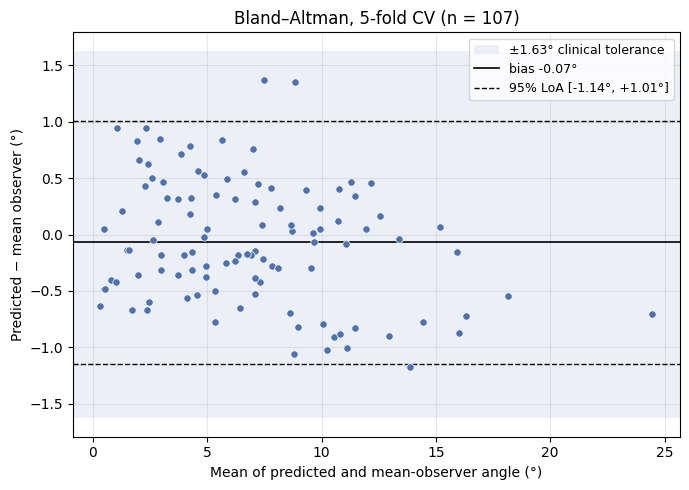

points outside ±1.63°: 0


In [10]:
m_ = (CV.gt_angle + CV.pred_angle) / 2; d_ = CV.pred_angle - CV.gt_angle
fig, ax = plt.subplots(figsize=(7, 5))
ax.axhspan(-CLINICAL_TOLERANCE_DEG, CLINICAL_TOLERANCE_DEG, color="#4C72B0", alpha=0.10, lw=0,
           label=f"±{CLINICAL_TOLERANCE_DEG}° clinical tolerance")
ax.scatter(m_, d_, s=28, color="#4C72B0", edgecolor="white", linewidth=0.5, zorder=3)
ax.axhline(cv_stats["ba_bias"], color="k", lw=1.2, label=f"bias {cv_stats['ba_bias']:+.2f}°")
for y in (cv_stats["ba_loa_low"], cv_stats["ba_loa_high"]):
    ax.axhline(y, color="k", ls="--", lw=1)
ax.plot([], [], "k--", lw=1, label=f"95% LoA [{cv_stats['ba_loa_low']:+.2f}°, {cv_stats['ba_loa_high']:+.2f}°]")
ax.set_xlabel("Mean of predicted and mean-observer angle (°)"); ax.set_ylabel("Predicted − mean observer (°)")
ax.set_title(f"Bland–Altman, 5-fold CV (n = {len(CV)})"); ax.legend(fontsize=9, loc="upper right"); ax.grid(alpha=0.3)
plt.tight_layout(); fig.savefig(os.path.join(OUT_DIR, "fig3_bland_altman_cv.png"), dpi=200); plt.show()
print(f"points outside ±{CLINICAL_TOLERANCE_DEG}°: {int((d_.abs() > CLINICAL_TOLERANCE_DEG).sum())}")

## Fig. 4 — Predicted vs mean-observer correction angle (CV circles, test triangles)

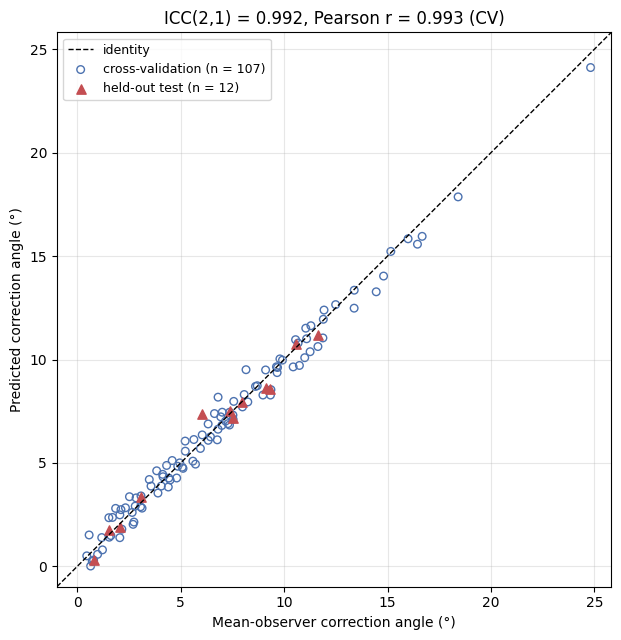

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
lo = min(CV.gt_angle.min(), CV.pred_angle.min(), TEST.gt_angle.min()) - 1
hi = max(CV.gt_angle.max(), CV.pred_angle.max(), TEST.gt_angle.max()) + 1
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="identity")
ax.scatter(CV.gt_angle, CV.pred_angle, s=30, facecolor="none", edgecolor="#4C72B0", label=f"cross-validation (n = {len(CV)})")
ax.scatter(TEST.gt_angle, TEST.pred_angle, s=45, marker="^", color="#C44E52", label=f"held-out test (n = {len(TEST)})")
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
ax.set_xlabel("Mean-observer correction angle (°)"); ax.set_ylabel("Predicted correction angle (°)")
ax.set_title(f"ICC(2,1) = {cv_stats['icc']:.3f}, Pearson r = {cv_stats['pearson']:.3f} (CV)")
ax.legend(loc="upper left", fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); fig.savefig(os.path.join(OUT_DIR, "fig4_pred_vs_gt.png"), dpi=200); plt.show()

## Fig. 5 — Example test radiograph

Ground-truth and predicted landmarks with the Miniaci/Fujisawa construction, from the hashed global model. The manuscript used `FIG5_FILE` (per-limb errors 0.15° / 0.72° with the replaced model); change it in the config to pick another radiograph.

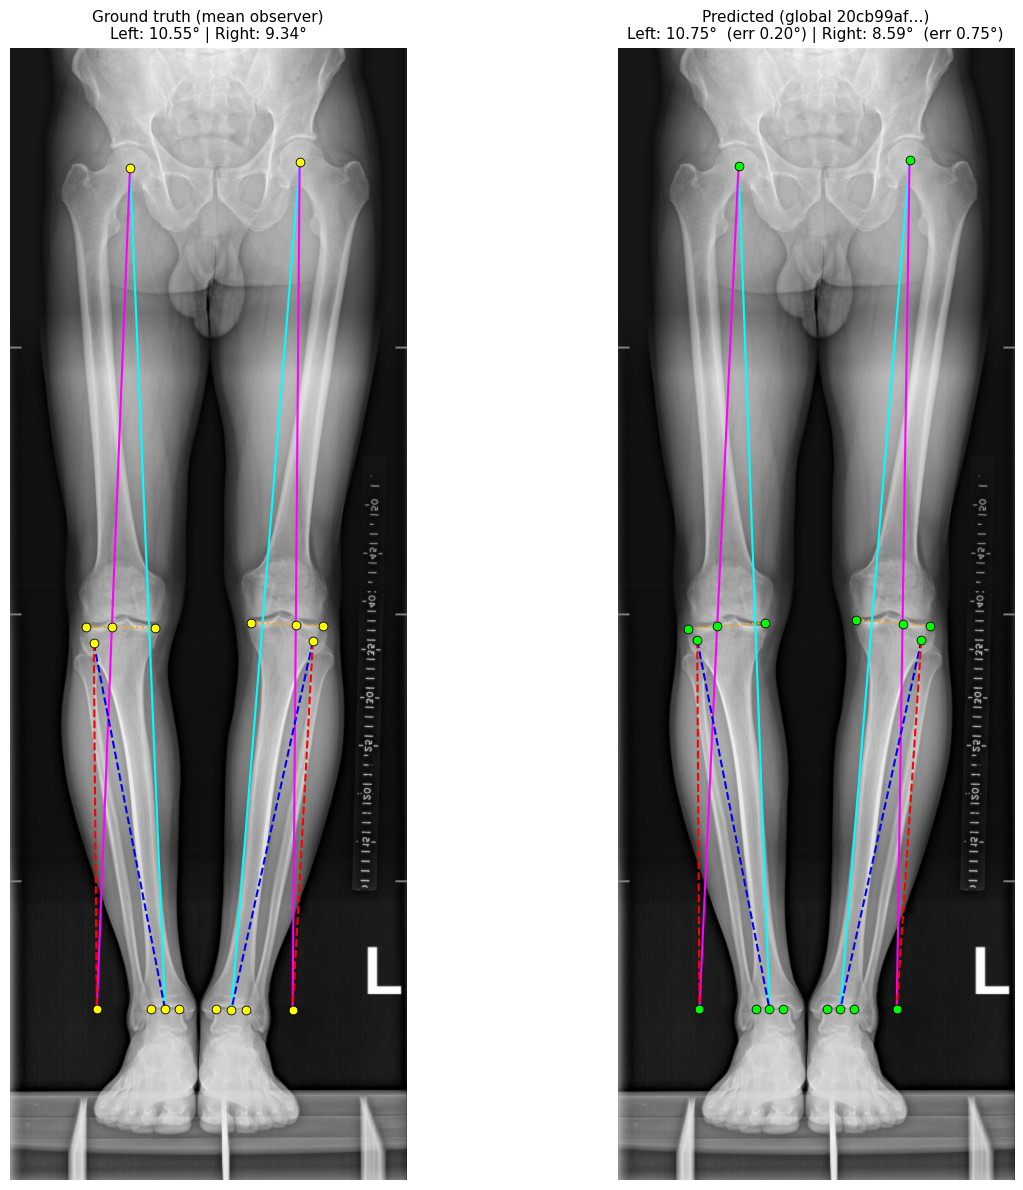

32_0.png: per-limb errors Left 0.20°, Right 0.75°   (manuscript: 0.15° / 0.72°, replaced model)


In [12]:
assert FIG5_FILE in TEST_IMAGES, f"{FIG5_FILE} is not in the test split: {TEST_FILES}"
item = TEST_IMAGES[FIG5_FILE]
img = Image.open(item["img_path"]).convert("RGB")

def side_points(coords, base):
    pts = {name: map_global_to_orig(coords[base + i], item["orig_size"], TARGET_SIZE) for i, name in enumerate(_SIDE_KEYS)}
    alpha, fuji, ank, targ = evaluate_side_geometry(pts)
    pts.update(fujisawa=fuji, ankle_c=ank, target_at_ankle=targ)
    return alpha, pts

fig, axes = plt.subplots(1, 2, figsize=(14, 12))
errors = {}
for ax, which in zip(axes, ["gt", "pred"]):
    ax.imshow(img, cmap="gray"); ax.axis("off")
    lines = []
    for base, side in [(0, "Left"), (6, "Right")]:
        if (item["gt"][base:base + 6, 0] < 0).any():
            continue
        a, pts = side_points(item[which], base)
        a_gt, _ = side_points(item["gt"], base)
        if which == "pred":
            errors[side] = abs(a - a_gt)
        lines.append(f"{side}: {a:.2f}°" + (f"  (err {abs(a - a_gt):.2f}°)" if which == "pred" else ""))
        for k_name, c in pts.items():
            ax.scatter(c[0], c[1], s=40, color="yellow" if which == "gt" else "lime", edgecolors="black", linewidths=0.6, zorder=5)
        for (p, q, col, ls) in [("femur_head", "ankle_c", "cyan", "-"), ("femur_head", "target_at_ankle", "magenta", "-"),
                                ("knee_inner", "knee_outer", "orange", ":"), ("ost_point", "ankle_c", "blue", "--"),
                                ("ost_point", "target_at_ankle", "red", "--")]:
            ax.plot([pts[p][0], pts[q][0]], [pts[p][1], pts[q][1]], color=col, ls=ls, lw=1.5, zorder=4)
    ax.set_title(("Ground truth (mean observer)" if which == "gt" else f"Predicted (global {SHA['global'][:8]}…)")
                 + "\n" + " | ".join(lines), fontsize=11)
plt.tight_layout(); fig.savefig(os.path.join(OUT_DIR, "fig5_example_test_radiograph.png"), dpi=200); plt.show()
print(f"{FIG5_FILE}: per-limb errors " + ", ".join(f"{s} {e:.2f}°" for s, e in errors.items())
      + f"   (manuscript: {PAPER['fig5_errors'][0]}° / {PAPER['fig5_errors'][1]}°, replaced model)")

## D. Fig. 1 — Training progression of the global model

Fig. 1 cannot be regenerated without retraining, but the 2000-epoch log of the run that produced the hashed global model is saved in `hto_correction_angles.ipynb`'s output. It is re-plotted here, and linked to the hashed weights: the checkpoint was saved at the epoch with the lowest validation keypoint MSE, so rescoring it on the fixed validation split must reproduce that minimum.

training log: 2000 epochs from hto_correction_angles.ipynb (sha256 ccf18edfdaf1…), checkpoint written to ['kfolds_models/best_model_global.pt']
lowest validation MSE in log: 4.27 px² at epoch 1565
hashed global model on the validation split: MSE 4.27 px² -> MATCHES the log's best epoch: this log belongs to these weights.

convergence (first epoch reaching the level):
  PCK@0.05 >= 99%: epoch 300
  PCK@0.02 >= 99%: epoch 300
  PCK@0.01 >= 99%: epoch 311
  PCK@0.005 50-epoch mean first within 1 pt of its final value: epoch 1049
  (manuscript: 0.02/0.05 saturate ~epoch 300, 0.01 ~500, 0.005 plateaus ~1000)


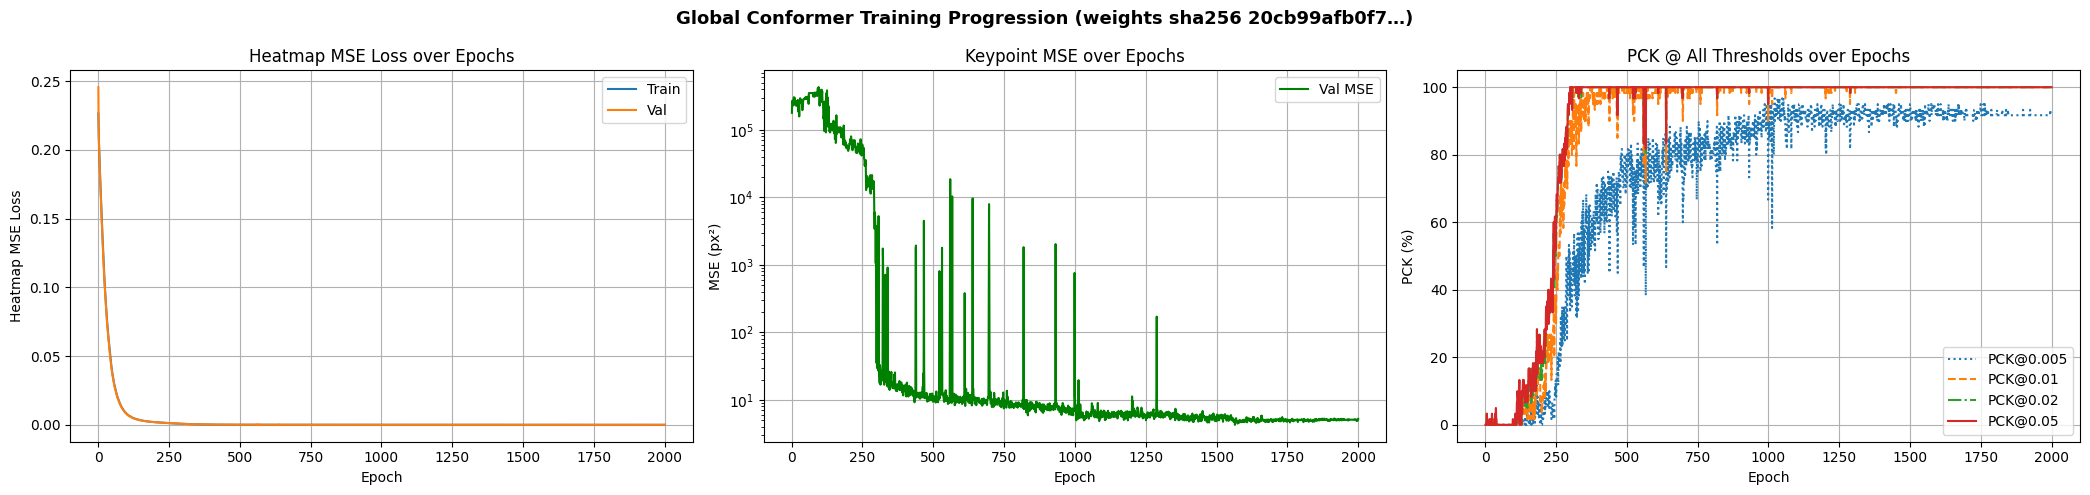

In [13]:
def parse_training_log(nb_path):
    nb = json.load(open(nb_path, encoding="utf-8"))
    for cell in nb["cells"]:
        txt = ""
        for o in cell.get("outputs", []):
            t = o.get("text", ""); txt += "".join(t) if isinstance(t, list) else t
        lines = [l for l in txt.splitlines() if l.startswith("Epoch ")]
        if "Best checkpoint loaded" in txt and len(lines) > 100:
            rows = []
            for l in lines:
                d = {}
                for part in l.split("|"):
                    part = part.strip()
                    if part.startswith("Epoch"):
                        d["epoch"] = int(part.split()[1].split("/")[0])
                    elif part.startswith("AngMAE"):
                        tr, va = part.split(":", 1)[1].split("°")[0].split("/")
                        d["ang_train"], d["ang_val"] = float(tr), float(va)
                    elif ":" in part:
                        k, v = part.split(":", 1)
                        d[k.strip()] = float(re.findall(r"[-+0-9.eE]+|nan", v)[0])
                rows.append(d)
            loaded = re.findall(r"Best checkpoint loaded from '([^']+)'", txt)
            return pd.DataFrame(rows).rename(columns={"Train(hm)": "train_loss", "Val": "val_loss", "MSE": "val_mse"}), loaded
    return None, None

LOG, loaded_from = parse_training_log(TRAINING_NOTEBOOK)
assert LOG is not None, f"no training log found in {TRAINING_NOTEBOOK}"
best = LOG.loc[LOG.val_mse.idxmin()]
print(f"training log: {len(LOG)} epochs from {TRAINING_NOTEBOOK} (sha256 {sha256_file(TRAINING_NOTEBOOK)[:12]}…), "
      f"checkpoint written to {loaded_from}")
print(f"lowest validation MSE in log: {best.val_mse:.2f} px² at epoch {int(best.epoch)}")

# link check: rescore the hashed global model on the fixed validation split
val_ds = GlobalRadiographKeypointDataset(COCO_JSON_PATH, split="val", split_ratios=SPLIT_RATIOS, **_kw)
_, val_kp, _ = score(model_global, val_ds, "global")
LOG_LINK_OK = abs(val_kp["mse"] - best.val_mse) <= 0.1
print(f"hashed global model on the validation split: MSE {val_kp['mse']:.2f} px² -> "
      + ("MATCHES the log's best epoch: this log belongs to these weights." if LOG_LINK_OK else
         f"does NOT match ({val_kp['mse'] - best.val_mse:+.2f} px²): the log may be from a different run."))

# convergence landmarks quoted in the manuscript text
def first_epoch(col, thr):
    hit = LOG.index[LOG[col] >= thr]
    return int(LOG.loc[hit[0], "epoch"]) if len(hit) else None
print("\nconvergence (first epoch reaching the level):")
for col in ["PCK@0.05", "PCK@0.02", "PCK@0.01"]:
    print(f"  {col} >= 99%: epoch {first_epoch(col, 99.0)}")
plateau = LOG["PCK@0.005"].rolling(50).mean()
print(f"  PCK@0.005 50-epoch mean first within 1 pt of its final value: epoch "
      f"{int(LOG.loc[(plateau >= plateau.iloc[-1] - 1).idxmax(), 'epoch'])}")
print("  (manuscript: 0.02/0.05 saturate ~epoch 300, 0.01 ~500, 0.005 plateaus ~1000)")

fig, axes = plt.subplots(1, 3, figsize=(21, 5))
axes[0].plot(LOG.epoch, LOG.train_loss, label="Train"); axes[0].plot(LOG.epoch, LOG.val_loss, label="Val")
axes[0].set_title("Heatmap MSE Loss over Epochs"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Heatmap MSE Loss")
axes[0].legend(); axes[0].grid(True)
axes[1].plot(LOG.epoch, LOG.val_mse, color="green", label="Val MSE")
axes[1].set_title("Keypoint MSE over Epochs"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MSE (px²)")
axes[1].set_yscale("log"); axes[1].legend(); axes[1].grid(True)
for col, ls in [("PCK@0.005", ":"), ("PCK@0.01", "--"), ("PCK@0.02", "-."), ("PCK@0.05", "-")]:
    axes[2].plot(LOG.epoch, LOG[col], ls=ls, label=col)
axes[2].set_title("PCK @ All Thresholds over Epochs"); axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("PCK (%)")
axes[2].legend(); axes[2].grid(True)
plt.suptitle(f"Global Conformer Training Progression (weights sha256 {SHA['global'][:12]}…)", fontsize=13, fontweight="bold")
plt.tight_layout(); fig.savefig(os.path.join(OUT_DIR, "fig1_training_progression.png"), dpi=200); plt.show()
LOG.to_csv(os.path.join(OUT_DIR, "global_training_log.csv"), index=False)

## E. Save the Record

In [14]:
record = dict(
    generated_at=datetime.datetime.now().isoformat(timespec="seconds"),
    environment=dict(torch=torch.__version__, device=str(device), gpu=GPU_NAME),
    weights=MANIFEST.to_dict(orient="records"),
    splits=dict(seed=SEED, n_radiographs=len(full_ds), kfold=dict(n_splits=N_FOLDS, shuffle=True, random_state=SEED),
                cv_val_files={k: dict(files=v, sha256=fingerprint(v)) for k, v in FOLD_FILES.items()},
                test_files=dict(files=TEST_FILES, sha256=fingerprint(TEST_FILES))),
    cross_validation=dict(pooled=cv_stats, keypoints=KP, folds=FOLDS.to_dict(orient="records"),
                          consistent_with_published=bool(cv_ok)),
    test=dict(stats=test_stats, keypoints=test_kp),
    figure5=dict(file=FIG5_FILE, per_limb_errors=errors),
    training_log=dict(notebook=TRAINING_NOTEBOOK, epochs=len(LOG), best_epoch=int(best.epoch),
                      best_val_mse_log=float(best.val_mse), val_mse_rescored=val_kp["mse"],
                      linked_to_hashed_weights=bool(LOG_LINK_OK)),
    published=PAPER,
)
with open(os.path.join(OUT_DIR, "paper_results.json"), "w") as f:
    json.dump(record, f, indent=2, default=float)
print("Saved to", OUT_DIR + "/:")
for f in sorted(os.listdir(OUT_DIR)):
    print("  ", f)

Saved to paper_results/:
   cv_folds.csv
   cv_hemispheres.csv
   fig1_training_progression.png
   fig2_cv_summary.png
   fig3_bland_altman_cv.png
   fig4_pred_vs_gt.png
   fig5_example_test_radiograph.png
   global_training_log.csv
   paper_results.json
   table1_regenerated_vs_published.csv
   test_hemispheres.csv
   weights_manifest.csv


## Outputs (`paper_results/`)

| File | Contents |
| --- | --- |
| `paper_results.json` | everything below plus hashes, split fingerprints, GPU, published values |
| `table1_regenerated_vs_published.csv` | Table 1, regenerated vs published, with Δ |
| `cv_hemispheres.csv`, `cv_folds.csv` | per-hemisphere CV angles; per-fold keypoint and angle metrics |
| `test_hemispheres.csv` | per-hemisphere test angles |
| `global_training_log.csv` | parsed 2000-epoch training log |
| `fig1_…png` – `fig5_…png` | regenerated figures (200 dpi) |
| `weights_manifest.csv` | SHA-256 of all six models |